In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import joblib
import os

from sklearn.ensemble import IsolationForest

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
df = pd.read_csv("../data/processed/features.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (23376, 170)


In [6]:
df.head()

,interval_start,equipment_ID,count_sum,A_028,A_029,A_024,A_045,A_001,A_058,A_064,...,A_053,A_054,A_060,A_061,production_rolling_6h,downtime_rolling_6h,production_change,downtime_change,performance_change,health_score
0,2020-01-01 14:00:00,s_1,4,0.0,0,0,NaN,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,0.861729,0.052261,0.000000,0.000000,0.000000,99.906124
1,2020-01-01 15:00:00,s_1,2,0.0,0,0,NaN,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,0.866313,0.084982,0.009168,0.065443,-0.008692,99.870897
2,2020-01-01 17:00:00,s_1,1,0.0,0,0,NaN,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,0.903703,0.063827,0.107586,-0.096186,-0.011399,99.978483
3,2020-01-01 18:00:00,s_1,4,0.0,0,0,NaN,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,0.795544,0.164966,-0.507417,0.446867,0.000000,99.531616
4,2020-01-01 19:00:00,s_1,1,0.0,0,0,NaN,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,0.833840,0.133529,0.515958,-0.460606,0.005198,99.987024


In [7]:
print("Number of columns:", len(df.columns))

print("\nColumns:")
for column in df.columns:
    print(column)

Number of columns: 170

Columns:
interval_start
equipment_ID
count_sum
A_028
A_029
A_024
A_045
A_001
A_058
A_064
A_030
A_101
A_002
A_107
A_056
A_015
A_032
A_026
A_003
A_008
A_078
A_070
A_004
A_005
A_009
A_016
A_010
A_027
A_020
A_017
A_048
A_022
A_011
A_012
A_013
A_042
A_023
A_034
A_036
A_079
A_077
A_090
A_021
A_049
A_006
#changes
%idle
%production
%downtime
%performance_loss
%scheduled_downtime
idle/idle
idle/production
idle/downtime
idle/performance_loss
idle/scheduled_downtime
production/idle
production/production
production/downtime
production/performance_loss
production/scheduled_downtime
downtime/idle
downtime/production
downtime/downtime
downtime/performance_loss
downtime/scheduled_downtime
performance_loss/idle
performance_loss/production
performance_loss/downtime
performance_loss/performance_loss
performance_loss/scheduled_downtime
scheduled_downtime/idle
scheduled_downtime/production
scheduled_downtime/downtime
scheduled_downtime/performance_loss
scheduled_downtime/scheduled_d

In [8]:
duplicate_columns = df.columns[df.columns.duplicated()].tolist()

print("Duplicate column names:")

if duplicate_columns:
    print(duplicate_columns)
else:
    print("No duplicate column names found.")

Duplicate column names:
No duplicate column names found.


In [9]:
df = df.loc[:, ~df.columns.duplicated()].copy()

print("Duplicate column names removed.")
print("New shape:", df.shape)

Duplicate column names removed.
New shape: (23376, 170)


In [10]:
required_columns = [
    "equipment_ID",
    "%production",
    "%downtime",
    "%idle",
    "%performance_loss",
    "%scheduled_downtime",
    "#changes"
]

print("Checking required columns...\n")

for column in required_columns:
    if column in df.columns:
        print("FOUND   :", column)
    else:
        print("MISSING :", column)

Checking required columns...

FOUND   : equipment_ID
FOUND   : %production
FOUND   : %downtime
FOUND   : %idle
FOUND   : %performance_loss
FOUND   : %scheduled_downtime
FOUND   : #changes


In [11]:
features = [
    "%production",
    "%downtime",
    "%idle",
    "%performance_loss",
    "%scheduled_downtime",
    "#changes"
]

features = [
    column for column in features
    if column in df.columns
]

print("Features used for anomaly detection:")
print(features)

Features used for anomaly detection:
['%production', '%downtime', '%idle', '%performance_loss', '%scheduled_downtime', '#changes']


In [12]:
X = df[features].copy()

print("X shape:", X.shape)
X.head()

X shape: (23376, 6)


,%production,%downtime,%idle,%performance_loss,%scheduled_downtime,#changes
0,0.861729,0.052261,0.021523,0.020092,0.044395,18.0
1,0.870897,0.117704,0.000000,0.011399,0.000000,5.0
2,0.978483,0.021517,0.000000,0.000000,0.000000,2.0
3,0.471066,0.468384,0.000000,0.000000,0.060550,8.0
4,0.987024,0.007778,0.000000,0.005198,0.000000,3.0


In [13]:
for column in features:
    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    )

print(X.dtypes)

%production            float64
%downtime              float64
%idle                  float64
%performance_loss      float64
%scheduled_downtime    float64
#changes               float64
dtype: object


In [14]:
print("Missing values:")
print(X.isnull().sum())

Missing values:
%production            0
%downtime              0
%idle                  0
%performance_loss      0
%scheduled_downtime    0
#changes               0
dtype: int64


In [15]:
X = X.fillna(X.median(numeric_only=True))

print("Missing values after cleaning:")
print(X.isnull().sum())

Missing values after cleaning:
%production            0
%downtime              0
%idle                  0
%performance_loss      0
%scheduled_downtime    0
#changes               0
dtype: int64


In [16]:
print("Infinite values before cleaning:")

print(
    np.isinf(X.select_dtypes(include=np.number))
    .sum()
    .sum()
)

Infinite values before cleaning:
0


In [17]:
anomaly_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

print("Isolation Forest model created.")

Isolation Forest model created.


In [18]:
anomaly_model.fit(X)

print("Isolation Forest trained successfully.")

Isolation Forest trained successfully.


In [19]:
df["anomaly_prediction"] = anomaly_model.predict(X)

print(
    df["anomaly_prediction"].value_counts()
)

anomaly_prediction
 1    22207
-1     1169
Name: count, dtype: int64


In [20]:
df["is_anomaly"] = (
    df["anomaly_prediction"] == -1
)

print(df["is_anomaly"].value_counts())

is_anomaly
False    22207
True      1169
Name: count, dtype: int64


In [21]:
df["anomaly_score"] = (
    anomaly_model.decision_function(X)
)

print(
    df["anomaly_score"].describe()
)

count    23376.000000
mean         0.146554
std          0.067212
min         -0.109831
25%          0.112439
50%          0.173219
75%          0.197126
max          0.219494
Name: anomaly_score, dtype: float64


In [22]:
score_min = df["anomaly_score"].min()
score_max = df["anomaly_score"].max()

df["anomaly_risk_score"] = (
    (score_max - df["anomaly_score"])
    / (score_max - score_min)
    * 100
)

df["anomaly_risk_score"] = (
    df["anomaly_risk_score"]
    .clip(0, 100)
)

print(
    df["anomaly_risk_score"].describe()
)

count    23376.000000
mean        22.148138
std         20.409066
min          0.000000
25%          6.791905
50%         14.051325
75%         32.507206
max        100.000000
Name: anomaly_risk_score, dtype: float64


In [23]:
total_records = len(df)

anomaly_count = df["is_anomaly"].sum()

normal_count = total_records - anomaly_count

anomaly_percentage = (
    anomaly_count / total_records * 100
)

print("Total records   :", total_records)
print("Normal records  :", normal_count)
print("Anomaly records :", anomaly_count)
print(
    "Anomaly rate    :",
    round(anomaly_percentage, 2),
    "%"
)

Total records   : 23376
Normal records  : 22207
Anomaly records : 1169
Anomaly rate    : 5.0 %


In [25]:
print(
    df["is_anomaly"]
    .value_counts()
    .rename({
        False: "Normal",
        True: "Anomaly"
    })
)

is_anomaly
Normal     22207
Anomaly     1169
Name: count, dtype: int64


In [26]:
machine_anomalies = (
    df[df["is_anomaly"]]
    .groupby("equipment_ID")
    .size()
    .reset_index(name="anomaly_count")
    .sort_values(
        "anomaly_count",
        ascending=False
    )
)

machine_anomalies

,equipment_ID,anomaly_count
0,s_1,421
1,s_2,231
2,s_3,218
3,s_4,160
4,s_5,139


In [27]:
machine_summary = (
    df.groupby("equipment_ID")
    .agg(
        total_records=("equipment_ID", "size"),
        anomaly_count=("is_anomaly", "sum")
    )
    .reset_index()
)

machine_summary["anomaly_rate"] = (
    machine_summary["anomaly_count"]
    / machine_summary["total_records"]
    * 100
)

machine_summary = (
    machine_summary
    .sort_values(
        "anomaly_rate",
        ascending=False
    )
)

machine_summary

,equipment_ID,total_records,anomaly_count,anomaly_rate
1,s_2,2725,231,8.477064
2,s_3,2976,218,7.325269
0,s_1,8973,421,4.691853
3,s_4,3959,160,4.041425
4,s_5,4743,139,2.930635


In [28]:
machine_operational_summary = (
    df.groupby("equipment_ID")
    .agg(
        total_records=("equipment_ID", "size"),
        anomaly_count=("is_anomaly", "sum"),
        average_production=(
            "%production",
            "mean"
        ),
        average_downtime=(
            "%downtime",
            "mean"
        ),
        average_idle=(
            "%idle",
            "mean"
        ),
        average_performance_loss=(
            "%performance_loss",
            "mean"
        ),
        average_health_score=(
            "health_score",
            "mean"
        )
    )
    .reset_index()
)

machine_operational_summary["anomaly_rate"] = (
    machine_operational_summary["anomaly_count"]
    / machine_operational_summary["total_records"]
    * 100
)

machine_operational_summary = (
    machine_operational_summary
    .sort_values(
        "anomaly_rate",
        ascending=False
    )
)

machine_operational_summary

,equipment_ID,total_records,anomaly_count,average_production,average_downtime,average_idle,average_performance_loss,average_health_score,anomaly_rate
1,s_2,2725,231,0.470678,0.191123,0.167595,0.114255,99.527027,8.477064
2,s_3,2976,218,0.705137,0.140759,0.060993,0.071125,99.727122,7.325269
0,s_1,8973,421,0.632548,0.159515,0.035710,0.111561,99.693214,4.691853
3,s_4,3959,160,0.561688,0.085959,0.087601,0.254994,99.571446,4.041425
4,s_5,4743,139,0.735361,0.082670,0.063501,0.112397,99.741431,2.930635


In [29]:
worst_machine = machine_summary.iloc[0]

print(
    "Machine with highest anomaly rate:",
    worst_machine["equipment_ID"]
)

print(
    "Anomaly rate:",
    round(
        worst_machine["anomaly_rate"],
        2
    ),
    "%"
)

Machine with highest anomaly rate: s_2
Anomaly rate: 8.48 %


In [30]:
top_anomalies = (
    df[df["is_anomaly"]]
    .sort_values(
        "anomaly_risk_score",
        ascending=False
    )
)

columns_to_display = [
    "equipment_ID",
    "interval_start",
    "%production",
    "%downtime",
    "%idle",
    "%performance_loss",
    "health_score",
    "anomaly_score",
    "anomaly_risk_score"
]

columns_to_display = [
    column
    for column in columns_to_display
    if column in top_anomalies.columns
]

top_anomalies[
    columns_to_display
].head(20)

,equipment_ID,interval_start,%production,%downtime,%idle,%performance_loss,health_score,anomaly_score,anomaly_risk_score
5290,s_1,2021-03-20 02:00:00,0.031040,0.248545,0.049903,0.060851,99.640701,-0.109831,100.000000
1368,s_1,2020-04-23 13:00:00,0.026033,0.115170,0.239189,0.041684,99.603957,-0.101256,97.396334
5767,s_1,2021-05-11 02:00:00,0.068566,0.261509,0.390686,0.061726,99.286079,-0.095637,95.689943
19765,s_5,2020-06-03 13:00:00,0.003788,0.029687,0.142504,0.050378,99.777432,-0.095100,95.526846
11642,s_2,2021-12-22 15:00:00,0.142365,0.037293,0.185675,0.065215,99.711817,-0.086231,92.833880
1364,s_1,2020-04-23 04:00:00,0.041890,0.030581,0.752771,0.053844,99.162803,-0.084305,92.249115
1406,s_1,2020-04-25 11:00:00,0.031704,0.011170,0.667007,0.121850,99.199973,-0.083632,92.044496
14948,s_4,2020-02-04 06:00:00,0.044062,0.088321,0.025065,0.020486,99.866128,-0.081458,91.384503
8582,s_1,2021-12-03 21:00:00,0.018145,0.100460,0.276093,0.023455,99.599992,-0.079710,90.853775
19376,s_5,2020-04-19 06:00:00,0.099546,0.008856,0.190783,0.700815,99.099546,-0.075383,89.539863


In [31]:
production_comparison = (
    df.groupby("is_anomaly")["%production"]
    .mean()
    .reset_index()
)

production_comparison["status"] = (
    production_comparison["is_anomaly"]
    .map({
        False: "Normal",
        True: "Anomaly"
    })
)

production_comparison

,is_anomaly,%production,status
0,False,0.662320,Normal
1,True,0.051615,Anomaly


In [32]:
downtime_comparison = (
    df.groupby("is_anomaly")["%downtime"]
    .mean()
    .reset_index()
)

downtime_comparison["status"] = (
    downtime_comparison["is_anomaly"]
    .map({
        False: "Normal",
        True: "Anomaly"
    })
)

downtime_comparison

,is_anomaly,%downtime,status
0,False,0.125498,Normal
1,True,0.270769,Anomaly


In [33]:
health_comparison = (
    df.groupby("is_anomaly")["health_score"]
    .mean()
    .reset_index()
)

health_comparison["status"] = (
    health_comparison["is_anomaly"]
    .map({
        False: "Normal",
        True: "Anomaly"
    })
)

health_comparison

,is_anomaly,health_score,status
0,False,99.684906,Normal
1,True,99.333211,Anomaly


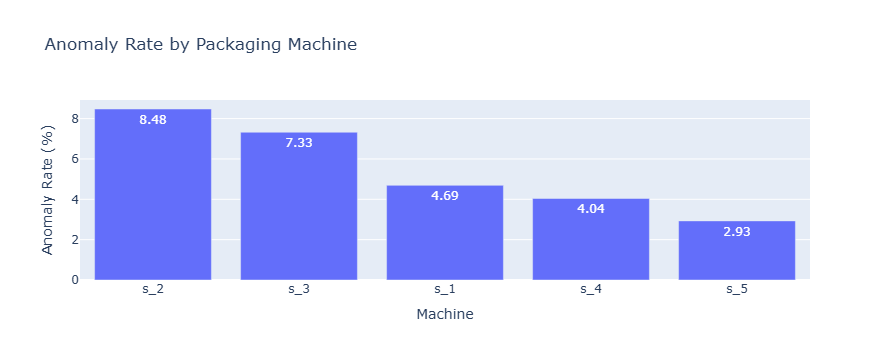

In [34]:
fig = px.bar(
    machine_summary,
    x="equipment_ID",
    y="anomaly_rate",
    title="Anomaly Rate by Packaging Machine",
    labels={
        "equipment_ID": "Machine",
        "anomaly_rate": "Anomaly Rate (%)"
    },
    text_auto=".2f"
)

fig.show()

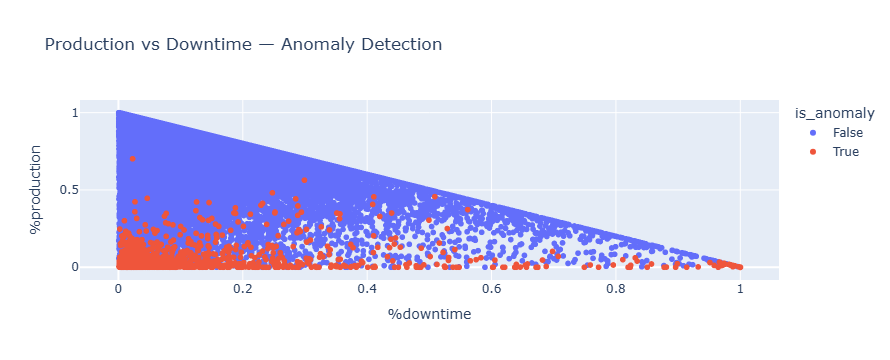

In [35]:
fig = px.scatter(
    df,
    x="%downtime",
    y="%production",
    color="is_anomaly",
    hover_data=[
        "equipment_ID",
        "interval_start",
        "health_score",
        "anomaly_risk_score"
    ],
    title="Production vs Downtime — Anomaly Detection"
)

fig.show()

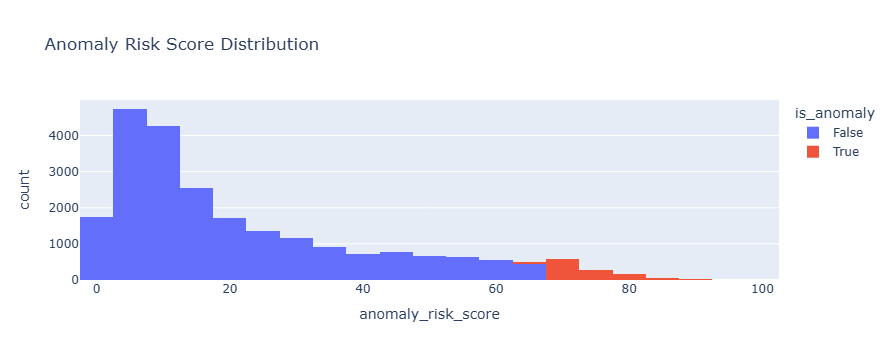

In [36]:
fig = px.histogram(
    df,
    x="anomaly_risk_score",
    color="is_anomaly",
    nbins=50,
    title="Anomaly Risk Score Distribution"
)

fig.show()

In [37]:
os.makedirs(
    "../data/processed",
    exist_ok=True
)

In [38]:
df.to_csv(
    "../data/processed/anomaly_results.csv",
    index=False
)

print(
    "anomaly_results.csv saved successfully."
)

anomaly_results.csv saved successfully.


In [39]:
machine_summary.to_csv(
    "../data/processed/machine_anomaly_summary.csv",
    index=False
)

print(
    "machine_anomaly_summary.csv saved successfully."
)

machine_anomaly_summary.csv saved successfully.


In [40]:
machine_operational_summary.to_csv(
    "../data/processed/machine_operational_summary.csv",
    index=False
)

print(
    "machine_operational_summary.csv saved successfully."
)

machine_operational_summary.csv saved successfully.


In [41]:
os.makedirs(
    "../models",
    exist_ok=True
)

In [42]:
joblib.dump(
    {
        "model": anomaly_model,
        "features": features
    },
    "../models/anomaly_model.pkl"
)

print(
    "anomaly_model.pkl saved successfully."
)

anomaly_model.pkl saved successfully.


In [43]:
files_to_check = [
    "../data/processed/anomaly_results.csv",
    "../data/processed/machine_anomaly_summary.csv",
    "../data/processed/machine_operational_summary.csv",
    "../models/anomaly_model.pkl"
]

print("Checking output files...\n")

for file in files_to_check:

    if os.path.exists(file):
        print("FOUND     :", file)

    else:
        print("NOT FOUND :", file)

Checking output files...

FOUND     : ../data/processed/anomaly_results.csv
FOUND     : ../data/processed/machine_anomaly_summary.csv
FOUND     : ../data/processed/machine_operational_summary.csv
FOUND     : ../models/anomaly_model.pkl
